 CONFIGURANDO OPCIONES A Y B PARA CADA DATASET...
   BRAAKSC: A(K=50) | B(K=75)
   CERADSC: A(K=1500) | B(K=25)
   COGDX: A(K=1000) | B(K=75)

 PROCESANDO CONFIGURACIÓN: A-A-A
   A -> BRAAKSC (K=50)
   A -> CERADSC (K=1500)
   A -> COGDX (K=1000)

 GENES MAESTROS (Overlap Triple): 46
      PALM3, BBOF1, ERP44, PPDPF, KMT2D, SLC4A11, MPV17L2, TMCC2, ME2, ISYNA1, CAPZA1, FCHO1, CMTM4, RASGRP2, AGPAT1, HMGN2, NUCB1, PA2G4, PFKP, KIF1A...
1⃣ RESILIENCIA COGNITIVA: 2 genes


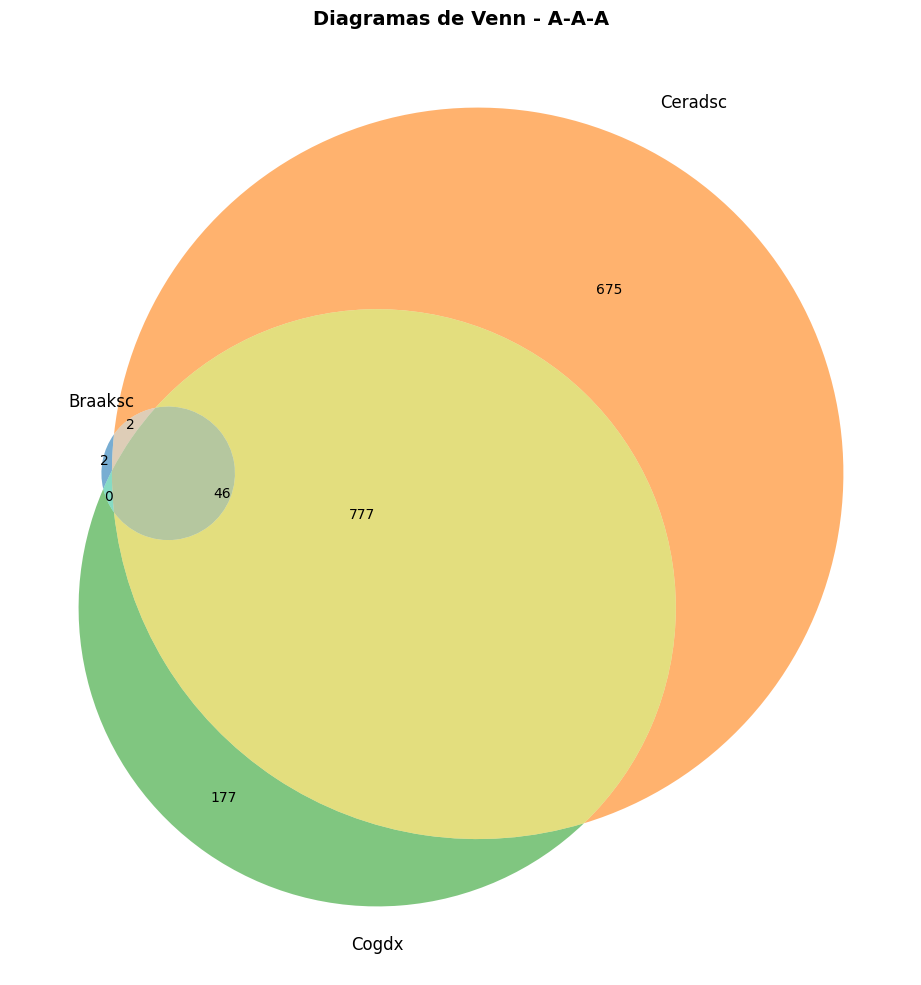


 PROCESANDO CONFIGURACIÓN: A-A-B
   A -> BRAAKSC (K=50)
   A -> CERADSC (K=1500)
   B -> COGDX (K=75)

 GENES MAESTROS (Overlap Triple): 25
      PALM3, PPDPF, TMCC2, ISYNA1, FCHO1, CMTM4, HMGN2, NUCB1, PFKP, KIF1A, LRRC4B, SETD1A, NIT1, SUPT7L, ZNF592, CIC, YY1, CHID1, ADAMTS2, TMEM107...
1⃣ RESILIENCIA COGNITIVA: 23 genes


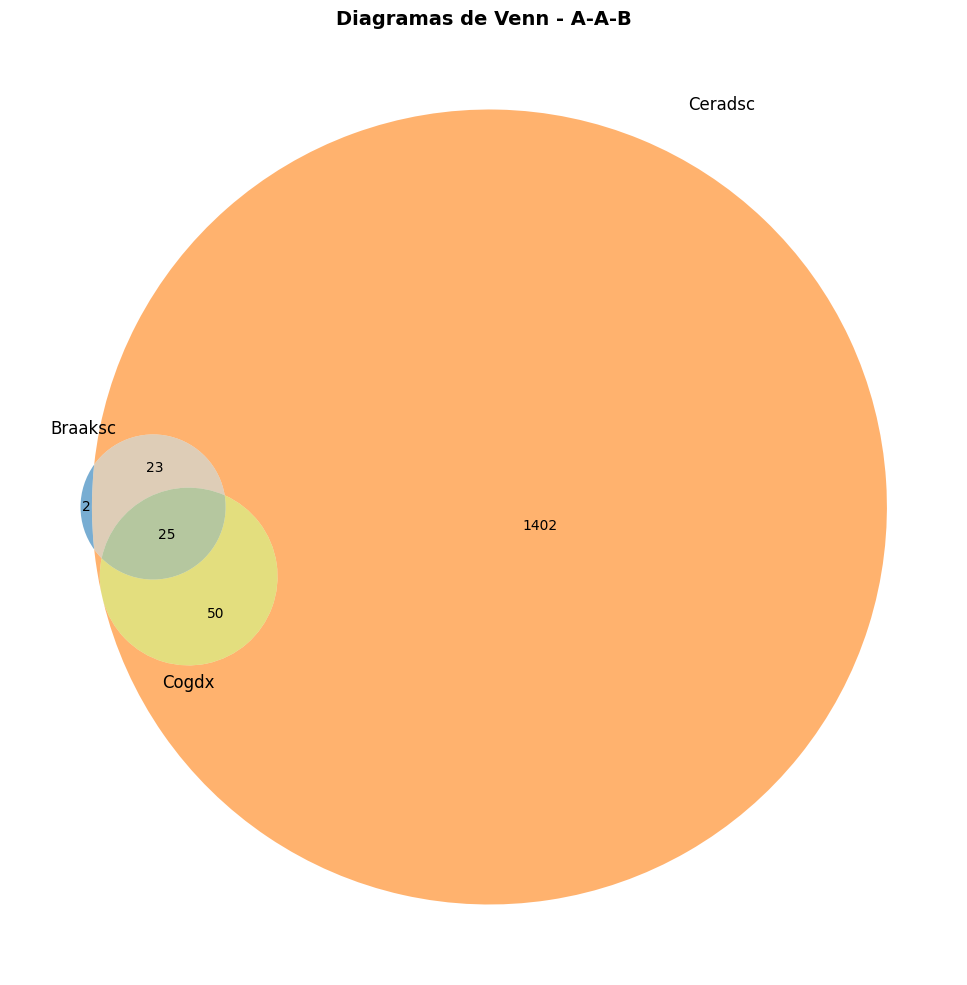


 PROCESANDO CONFIGURACIÓN: A-B-A
   A -> BRAAKSC (K=50)
   B -> CERADSC (K=25)
   A -> COGDX (K=1000)

 GENES MAESTROS (Overlap Triple): 16
      TMEM107, FCHO1, LRRC4B, PPDPF, CMTM4, ZNF592, HMGN2, DAB2IP, CHID1, DDOST, KIF1A, CIC, SETD1A, TMCC2, ISYNA1, ADAMTS2...
1⃣ RESILIENCIA COGNITIVA: 0 genes


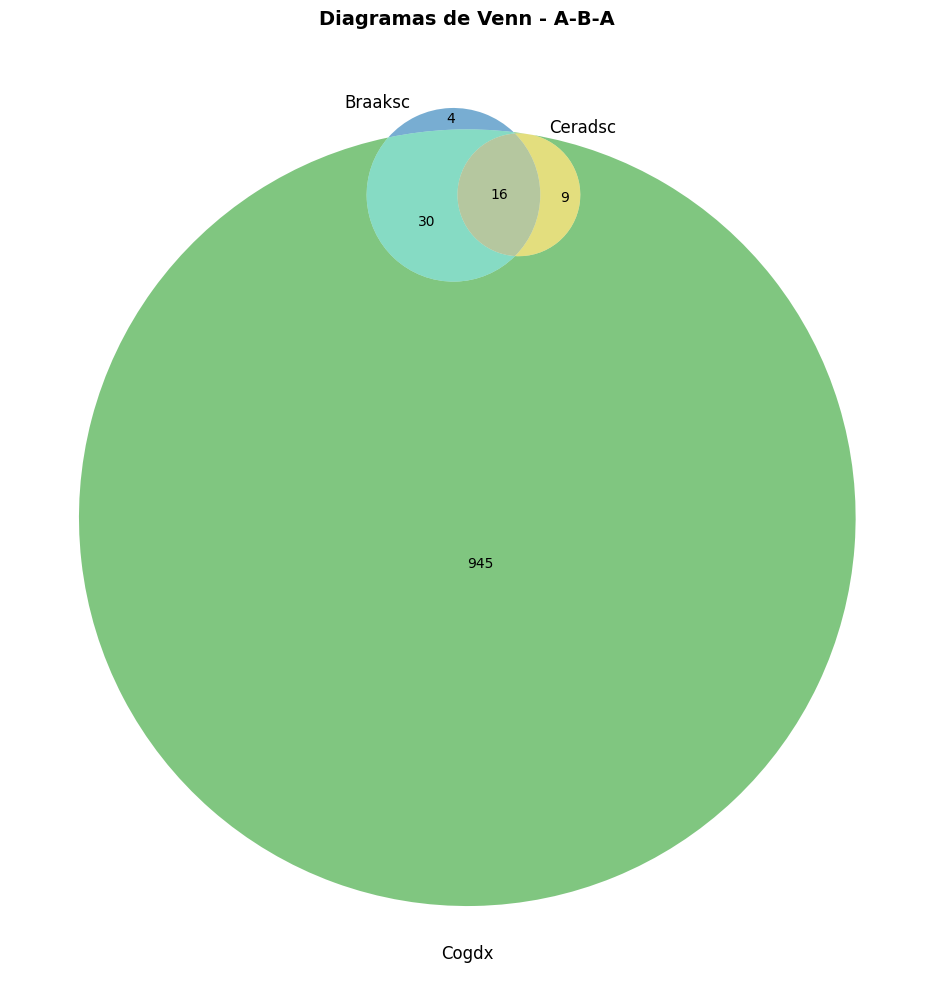


 PROCESANDO CONFIGURACIÓN: A-B-B
   A -> BRAAKSC (K=50)
   B -> CERADSC (K=25)
   B -> COGDX (K=75)

 GENES MAESTROS (Overlap Triple): 16
      TMEM107, FCHO1, LRRC4B, PPDPF, CMTM4, ZNF592, HMGN2, DAB2IP, CHID1, DDOST, KIF1A, CIC, SETD1A, TMCC2, ISYNA1, ADAMTS2...
1⃣ RESILIENCIA COGNITIVA: 0 genes


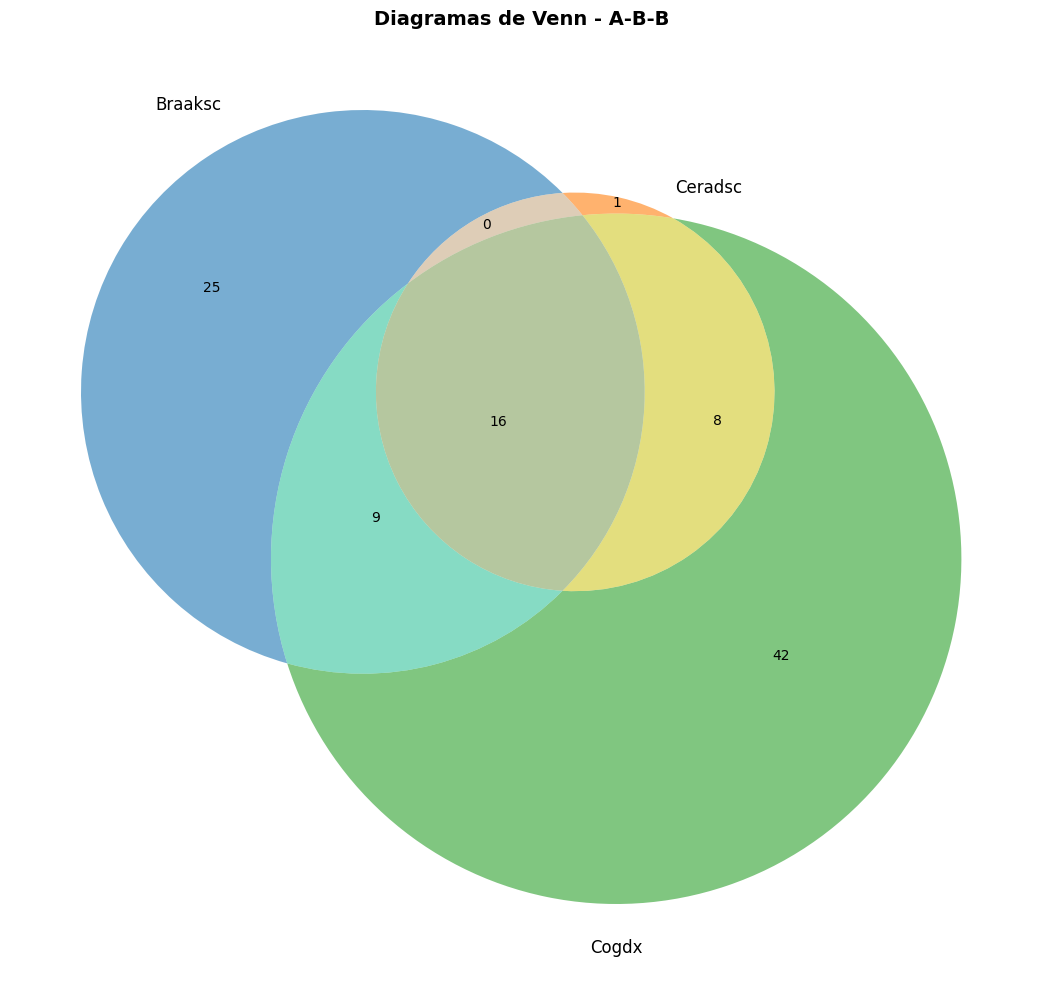


 PROCESANDO CONFIGURACIÓN: B-A-A
   B -> BRAAKSC (K=75)
   A -> CERADSC (K=1500)
   A -> COGDX (K=1000)

 GENES MAESTROS (Overlap Triple): 68
      PALM3, PDZD11, ERP44, PPDPF, BBOF1, EXOSC1, KMT2D, SLC4A11, CREBL2, PDHA1, ST3GAL3, MPV17L2, CRELD2, TMCC2, ME2, ISYNA1, CAPZA1, CXXC1, AMPD2, FCHO1...
1⃣ RESILIENCIA COGNITIVA: 5 genes


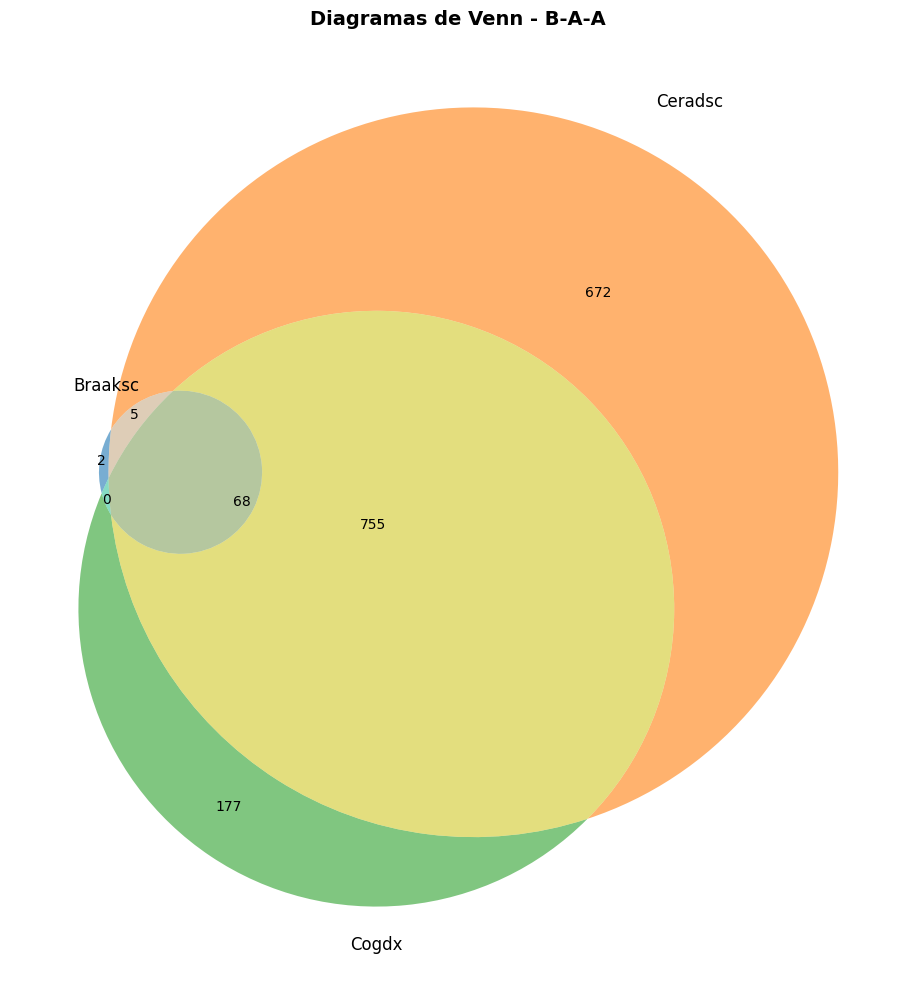


 PROCESANDO CONFIGURACIÓN: B-A-B
   B -> BRAAKSC (K=75)
   A -> CERADSC (K=1500)
   B -> COGDX (K=75)

 GENES MAESTROS (Overlap Triple): 30
      PALM3, PPDPF, TMCC2, ISYNA1, FCHO1, SLC6A12, CMTM4, AIG1, HMGN2, NUCB1, PFKP, KIF1A, LRRC4B, SETD1A, NIT1, SLC6A9, SUPT7L, PRPF4, ZNF592, CIC...
1⃣ RESILIENCIA COGNITIVA: 43 genes


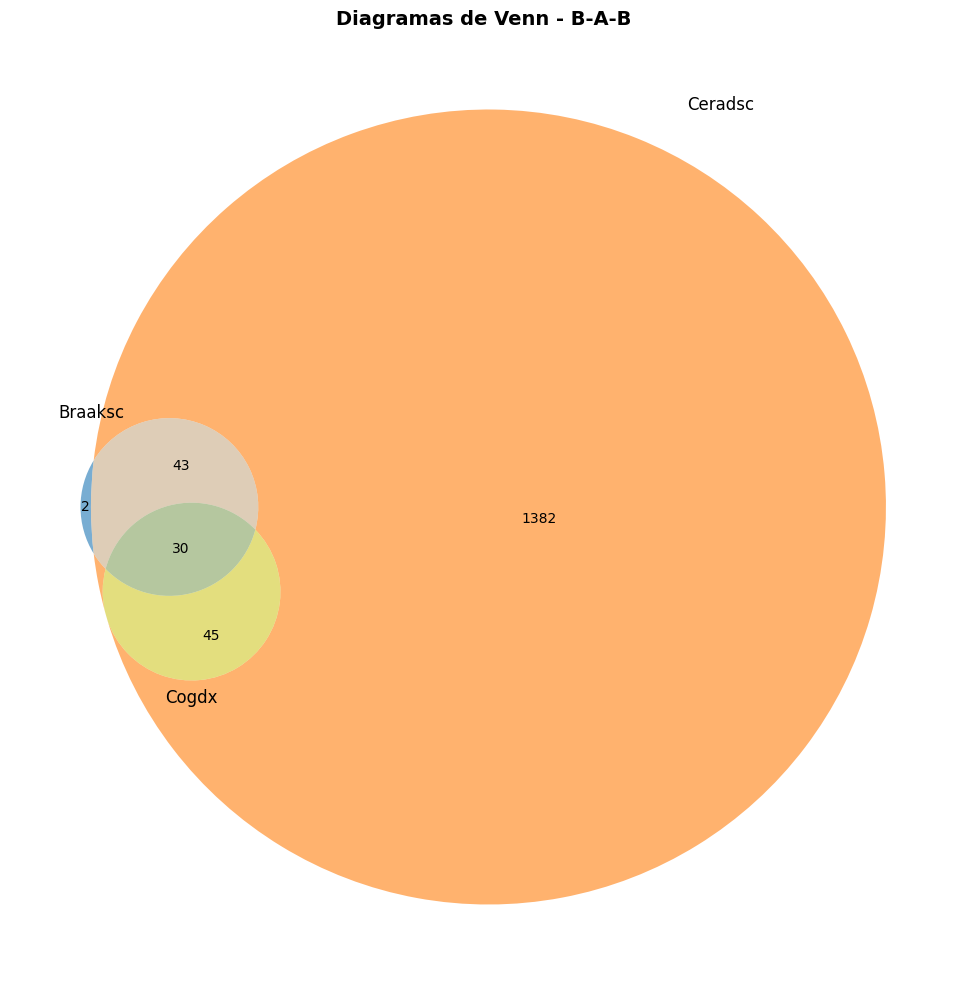


 PROCESANDO CONFIGURACIÓN: B-B-A
   B -> BRAAKSC (K=75)
   B -> CERADSC (K=25)
   A -> COGDX (K=1000)

 GENES MAESTROS (Overlap Triple): 18
      SLC6A9, TMEM107, FCHO1, SLC6A12, LRRC4B, PPDPF, CMTM4, ZNF592, HMGN2, DAB2IP, CHID1, DDOST, KIF1A, CIC, SETD1A, TMCC2, ISYNA1, ADAMTS2...
1⃣ RESILIENCIA COGNITIVA: 0 genes


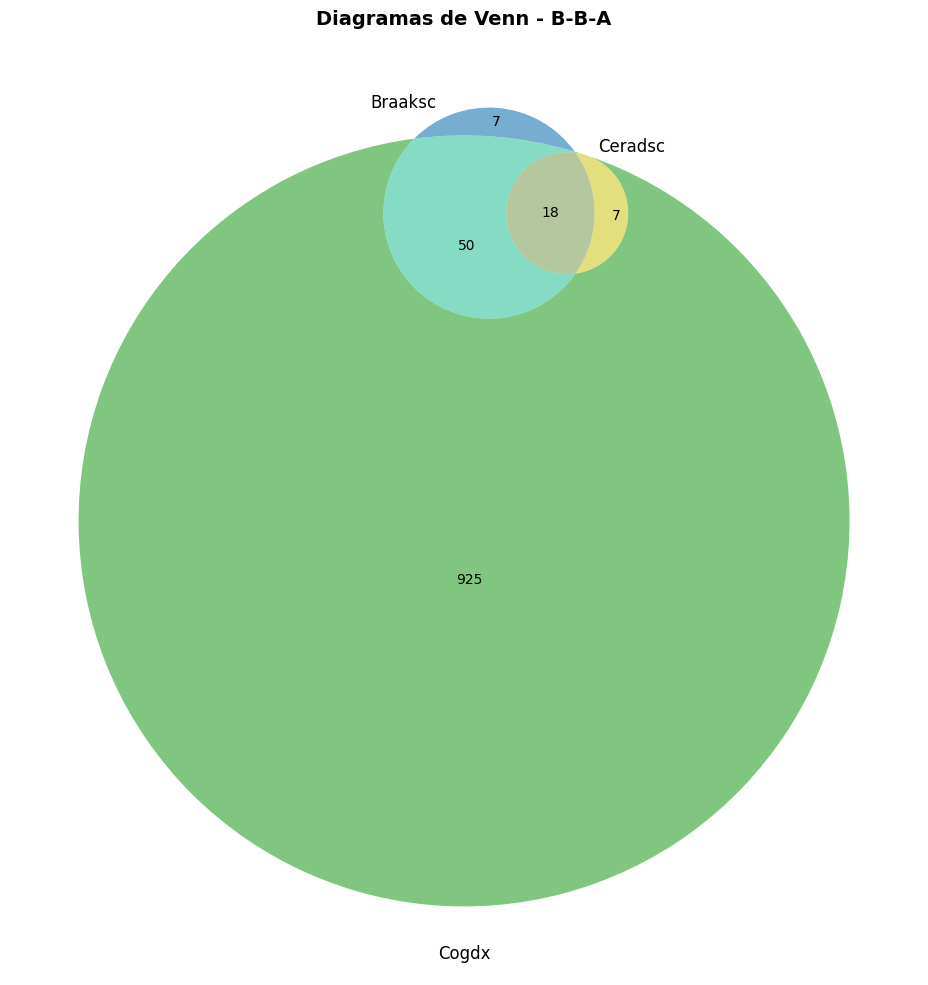


 PROCESANDO CONFIGURACIÓN: B-B-B
   B -> BRAAKSC (K=75)
   B -> CERADSC (K=25)
   B -> COGDX (K=75)

 GENES MAESTROS (Overlap Triple): 18
      SLC6A9, TMEM107, FCHO1, SLC6A12, LRRC4B, PPDPF, CMTM4, ZNF592, HMGN2, DAB2IP, CHID1, DDOST, KIF1A, CIC, SETD1A, TMCC2, ISYNA1, ADAMTS2...
1⃣ RESILIENCIA COGNITIVA: 0 genes


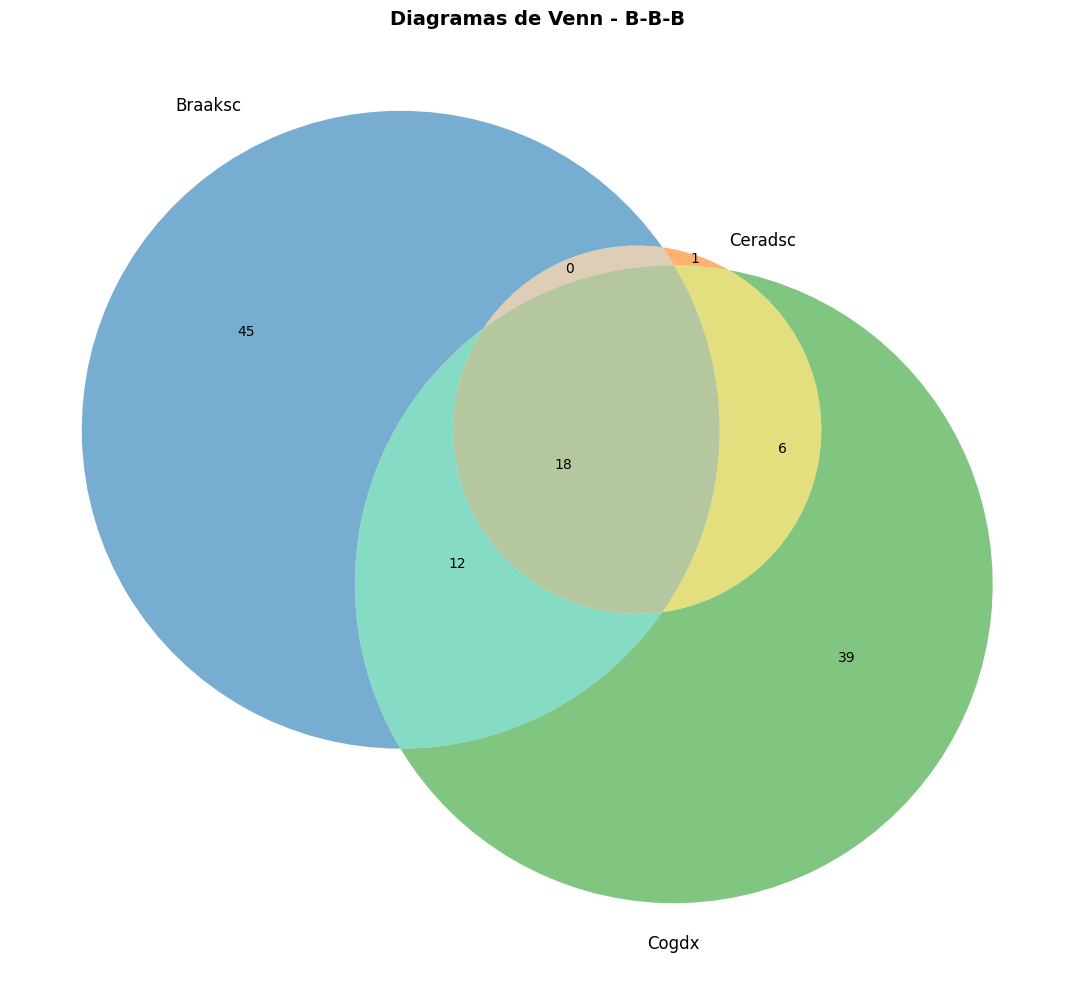


 ANÁLISIS DE LAS 8 COMBINACIONES FINALIZADO.


In [1]:
import os
import pandas as pd
import re
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from scipy.stats import wilcoxon
from statistics import mean

# ==================== CONFIGURACIÓN DE RUTAS ====================
RESULTS_DIR = "../results"
PARSIMONY_SUMMARY_PATH = "../best_k_selection/parsimony_analysis/parsimony_summary.csv"
K_VALUES = [25, 50, 75, 100, 500, 1000, 1500, 2500]
DATASETS_LIST = ["braaksc", "ceradsc", "cogdx"]

# Colores ANSI
GREEN, RED, YELLOW, BLUE = '\033[92m', '\033[91m', '\033[93m', '\033[94m'
CYAN, MAGENTA, BOLD, RESET = '\033[96m', '\033[95m', '\033[1m', '\033[0m'

PRINT_LIMIT = 50

# ==================== FUNCIONES DE CARGA DINÁMICA (CONTINUACIÓN) ====================

def get_winner_info(dataset, k):
    py_path = os.path.join(RESULTS_DIR, dataset, f"k_{k}", "best_analysis", f"{dataset}_best_dataset_k{k}.py")
    if not os.path.exists(py_path): return None
    with open(py_path, 'r', encoding='utf-8') as f:
        content = f.read()
    match = re.search(r"metodologia_ganador\s*=\s*['\"](.+?)['\"]", content)
    return match.group(1) if match else None

def get_dataset_path(dataset, k, winner_name):
    if not winner_name: return None
    base_name = f"genes-{dataset}"
    if "R2" in winner_name: filename = f"{base_name}-FR-{k}_train.csv"
    elif "R3" in winner_name: filename = f"{base_name}-resampling_FR-{k}_train.csv"
    else: filename = f"{base_name}_train.csv"
    return os.path.join(RESULTS_DIR, dataset, f"k_{k}", filename)

def load_metric_vector(dataset, k, method, metric="BA"):
    base = f"genes-{dataset}"
    if "R2" in method: suffix = f"_{base}-FR-{k}.csv"
    elif "R3" in method: suffix = f"_{base}-resampling_FR-{k}.csv"
    else: suffix = f"_{base}_k{k}.csv"
    csv_path = os.path.join(RESULTS_DIR, dataset, f"k_{k}", f"test_{metric}{suffix}")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        col = method if method in df.columns else method.split("-")[0]
        if col in df.columns: return df[col].values[:10]
    return None

def calculate_win_loss_winner(dataset):
    """Misma lógica que el script anterior para obtener la opción B"""
    scores_dict = {"BA": pd.DataFrame(), "F1": pd.DataFrame(), "PS": pd.DataFrame()}
    methods_found = {}
    for k in K_VALUES:
        meth = get_winner_info(dataset, k)
        if not meth: continue
        methods_found[f"K={k}"] = meth
        for m in ["BA", "F1", "PS"]:
            vec = load_metric_vector(dataset, k, meth, m)
            if vec is not None: scores_dict[m][f"K={k}"] = vec
    
    if scores_dict["BA"].empty: return None, None

    def get_net_wins(df):
        labels = df.columns
        wins = {l: 0 for l in labels}
        for i in range(len(labels)):
            for j in range(i + 1, len(labels)):
                col_i, col_j = df.iloc[:, i].values, df.iloc[:, j].values
                if not np.array_equal(col_i, col_j):
                    try:
                        _, p = wilcoxon(col_i, col_j)
                        if p < 0.05:
                            if mean(col_i) > mean(col_j): wins[labels[i]] += 1; wins[labels[j]] -= 1
                            else: wins[labels[j]] += 1; wins[labels[i]] -= 1
                    except: pass
        return wins

    w_ba, w_f1, w_ps = get_net_wins(scores_dict["BA"]), get_net_wins(scores_dict["F1"]), get_net_wins(scores_dict["PS"])
    total_wins = {k: w_ba[k] + w_f1[k] + w_ps[k] for k in w_ba.keys()}
    best_k_label = max(total_wins, key=total_wins.get)
    return int(best_k_label.replace("K=", "")), methods_found[best_k_label]

# ==================== LÓGICA DE OVERLAP ====================

def load_genes(dataset, k, winner):
    path = get_dataset_path(dataset, k, winner)
    if not path or not os.path.exists(path): return set()
    df_cols = pd.read_csv(path, nrows=0)
    return set(c for c in df_cols.columns if c.lower() != 'target')

def plot_venn_diagrams(gene_sets, config_name):
    A, B, C = gene_sets['braaksc'], gene_sets['ceradsc'], gene_sets['cogdx']
    fig = plt.figure(figsize=(12, 10))
    fig.suptitle(f'Diagramas de Venn - {config_name}', fontsize=14, fontweight='bold')
    
    colors_3 = ('#1f77b4', '#ff7f0e', '#2ca02c')
    ax = fig.add_subplot(111)
    venn3([A, B, C], set_labels=('Braaksc', 'Ceradsc', 'Cogdx'), set_colors=colors_3, alpha=0.6)
    plt.tight_layout()
    plt.show(block=False)
    plt.pause(1)

# ==================== PROCESO PRINCIPAL DINÁMICO ====================

if not os.path.exists(PARSIMONY_SUMMARY_PATH):
    print(f"{RED} Error: No existe el resumen de parsimonia.{RESET}"); exit()

df_pars = pd.read_csv(PARSIMONY_SUMMARY_PATH)
dataset_options = {}

print(f"{BOLD}{CYAN} CONFIGURANDO OPCIONES A Y B PARA CADA DATASET...{RESET}")

for ds in DATASETS_LIST:
    # Opción A: Parsimonia
    row = df_pars[df_pars['Dataset'] == ds].iloc[0]
    kA, methA = int(row['K_elegido']), row['Metodologia']
    
    # Opción B: Win-Loss (con regla de seguridad)
    kB_raw, methB_raw = calculate_win_loss_winner(ds)
    
    if kB_raw == kA and methB_raw == methA:
        # Si coinciden, B es el segundo mejor por parsimonia
        det_path = f"../best_k_selection/parsimony_analysis/metrics_per_k_{ds}.csv"
        df_det = pd.read_csv(det_path)
        pars_list = df_det[df_det['Elegido'] == 'SI'].sort_values(by='K')
        if len(pars_list) > 1:
            kB, methB = int(pars_list.iloc[1]['K']), pars_list.iloc[1]['Metodologia']
        else:
            kB, methB = (25, get_winner_info(ds, 25)) if kA != 25 else (50, get_winner_info(ds, 50))
    else:
        kB, methB = kB_raw, methB_raw
        
    dataset_options[ds] = {
        'A': {'k': kA, 'meth': methA},
        'B': {'k': kB, 'meth': methB}
    }
    print(f"   {ds.upper()}: A(K={kA}) | B(K={kB})")

# Generar todas las combinaciones (8 permutaciones)
combos = list(itertools.product(['A', 'B'], repeat=3))

for combo in combos:
    config_name = f"{combo[0]}-{combo[1]}-{combo[2]}"
    # Saltamos A-A-A si ya se hizo, pero aquí lo incluimos para análisis completo
    
    print(f"\n{BOLD}{'='*80}{RESET}")
    print(f"{BOLD}{MAGENTA} PROCESANDO CONFIGURACIÓN: {config_name}{RESET}")
    print(f"{BOLD}{'='*80}{RESET}")

    current_gene_sets = {}
    for i, ds in enumerate(DATASETS_LIST):
        opt = combo[i]
        params = dataset_options[ds][opt]
        current_gene_sets[ds] = load_genes(ds, params['k'], params['meth'])
        print(f"   {opt} -> {ds.upper()} (K={params['k']})")

    # Análisis de intersecciones (mismo bloque que tu script original)
    core = set.intersection(*current_gene_sets.values())
    print(f"\n{GREEN} GENES MAESTROS (Overlap Triple): {len(core)}{RESET}")
    if core: print(f"      {', '.join(list(core)[:20])}...")

    # Disociaciones (Resiliencia Cognitiva, etc)
    patho_no_clin = (current_gene_sets['braaksc'] & current_gene_sets['ceradsc']) - current_gene_sets['cogdx']
    print(f"{YELLOW}1⃣ RESILIENCIA COGNITIVA: {len(patho_no_clin)} genes{RESET}")
    
    # Diagrama
    plot_venn_diagrams(current_gene_sets, config_name)

print(f"\n{BOLD} ANÁLISIS DE LAS 8 COMBINACIONES FINALIZADO.{RESET}")
plt.show()

In [8]:
import os
import pandas as pd
import re
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from scipy.stats import wilcoxon
from statistics import mean

# ==================== CONFIGURACIÓN DE RUTAS ====================
RESULTS_DIR = "../results"
PARSIMONY_SUMMARY_PATH = "../best_k_selection/parsimony_analysis/parsimony_summary.csv"
K_VALUES = [25, 50, 75, 100, 500, 1000, 1500, 2500]
DATASETS_LIST = ["braaksc", "ceradsc", "cogdx"]

# NUEVA CONFIGURACIÓN DE SALIDA LOCAL
OUTPUT_DIR = "combinatorial_intersections_analysis"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Colores ANSI
GREEN, RED, YELLOW, BLUE = '\033[92m', '\033[91m', '\033[93m', '\033[94m'
CYAN, MAGENTA, BOLD, RESET = '\033[96m', '\033[95m', '\033[1m', '\033[0m'

# ==================== FUNCIONES DE CARGA ====================

def get_winner_info(dataset, k):
    py_path = os.path.join(RESULTS_DIR, dataset, f"k_{k}", "best_analysis", f"{dataset}_best_dataset_k{k}.py")
    if not os.path.exists(py_path): return None
    with open(py_path, 'r', encoding='utf-8') as f:
        content = f.read()
    match = re.search(r"metodologia_ganador\s*=\s*['\"](.+?)['\"]", content)
    return match.group(1) if match else None

def get_dataset_path(dataset, k, winner_name):
    if not winner_name: return None
    base_name = f"genes-{dataset}"
    if "R2" in winner_name: filename = f"{base_name}-FR-{k}_train.csv"
    elif "R3" in winner_name: filename = f"{base_name}-resampling_FR-{k}_train.csv"
    else: filename = f"{base_name}_train.csv"
    return os.path.join(RESULTS_DIR, dataset, f"k_{k}", filename)

def load_metric_vector(dataset, k, method, metric="BA"):
    base = f"genes-{dataset}"
    if "R2" in method: suffix = f"_{base}-FR-{k}.csv"
    elif "R3" in method: suffix = f"_{base}-resampling_FR-{k}.csv"
    else: suffix = f"_{base}_k{k}.csv"
    csv_path = os.path.join(RESULTS_DIR, dataset, f"k_{k}", f"test_{metric}{suffix}")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        col = method if method in df.columns else method.split("-")[0]
        if col in df.columns: return df[col].values[:10]
    return None

def calculate_win_loss_winner(dataset):
    scores_dict = {"BA": pd.DataFrame(), "F1": pd.DataFrame(), "PS": pd.DataFrame()}
    methods_found = {}
    for k in K_VALUES:
        meth = get_winner_info(dataset, k)
        if not meth: continue
        methods_found[f"K={k}"] = meth
        for m in ["BA", "F1", "PS"]:
            vec = load_metric_vector(dataset, k, meth, m)
            if vec is not None: scores_dict[m][f"K={k}"] = vec
    
    if scores_dict["BA"].empty: return None, None

    def get_net_wins(df):
        labels = df.columns
        wins = {l: 0 for l in labels}
        for i in range(len(labels)):
            for j in range(i + 1, len(labels)):
                col_i, col_j = df.iloc[:, i].values, df.iloc[:, j].values
                if not np.array_equal(col_i, col_j):
                    try:
                        _, p = wilcoxon(col_i, col_j)
                        if p < 0.05:
                            if mean(col_i) > mean(col_j): wins[labels[i]] += 1; wins[labels[j]] -= 1
                            else: wins[labels[j]] += 1; wins[labels[i]] -= 1
                    except: pass
        return wins

    w_ba, w_f1, w_ps = get_net_wins(scores_dict["BA"]), get_net_wins(scores_dict["F1"]), get_net_wins(scores_dict["PS"])
    total_wins = {k: w_ba[k] + w_f1[k] + w_ps[k] for k in w_ba.keys()}
    best_k_label = max(total_wins, key=total_wins.get)
    return int(best_k_label.replace("K=", "")), methods_found[best_k_label]

def load_genes(dataset, k, winner):
    path = get_dataset_path(dataset, k, winner)
    if not path or not os.path.exists(path): return set()
    df_cols = pd.read_csv(path, nrows=0)
    return set(c for c in df_cols.columns if c.lower() != 'target')

def save_analysis_results(config_name, gene_sets, core, patho_no_clin):
    """Guarda los resultados del análisis en un archivo de texto descriptivo."""
    file_path = os.path.join(OUTPUT_DIR, f"reporte_{config_name}.txt")
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(f"ANÁLISIS DE INTERSECCIÓN - CONFIGURACIÓN {config_name}\n")
        f.write("="*50 + "\n")
        for ds, genes in gene_sets.items():
            f.write(f"- {ds.upper()}: {len(genes)} genes\n")
        f.write(f"\nGENES MAESTROS (Overlap Triple): {len(core)}\n")
        f.write(f"LISTA: {', '.join(list(core))}\n")
        f.write(f"\nRESILIENCIA COGNITIVA: {len(patho_no_clin)} genes\n")
        f.write(f"LISTA: {', '.join(list(patho_no_clin))}\n")
    
    print(f"{BLUE} Reporte guardado: {os.path.relpath(file_path)}{RESET}")

def plot_and_save_venn(gene_sets, config_name):
    """Genera y guarda el diagrama de Venn."""
    A, B, C = gene_sets['braaksc'], gene_sets['ceradsc'], gene_sets['cogdx']
    fig = plt.figure(figsize=(10, 8))
    plt.title(f'Venn Diagram - Config {config_name}', fontsize=12, fontweight='bold')
    
    colors_3 = ('#1f77b4', '#ff7f0e', '#2ca02c')
    venn3([A, B, C], set_labels=('Braaksc', 'Ceradsc', 'Cogdx'), set_colors=colors_3, alpha=0.6)
    
    img_path = os.path.join(OUTPUT_DIR, f"venn_{config_name}.png")
    plt.savefig(img_path, bbox_inches='tight')
    plt.close(fig)
    print(f"{BLUE}  Imagen guardada:  {os.path.relpath(img_path)}{RESET}")

# ==================== PROCESO PRINCIPAL ====================

if not os.path.exists(PARSIMONY_SUMMARY_PATH):
    print(f"{RED} Error: No existe el resumen de parsimonia.{RESET}"); exit()

df_pars = pd.read_csv(PARSIMONY_SUMMARY_PATH)
dataset_options = {}

for ds in DATASETS_LIST:
    row = df_pars[df_pars['Dataset'] == ds].iloc[0]
    kA, methA = int(row['K_elegido']), row['Metodologia']
    kB_raw, methB_raw = calculate_win_loss_winner(ds)
    
    if kB_raw == kA and methB_raw == methA:
        det_path = f"../best_k_selection/parsimony_analysis/metrics_per_k_{ds}.csv"
        df_det = pd.read_csv(det_path)
        pars_list = df_det[df_det['Elegido'] == 'SI'].sort_values(by='K')
        if len(pars_list) > 1:
            kB, methB = int(pars_list.iloc[1]['K']), pars_list.iloc[1]['Metodologia']
        else:
            kB, methB = (25, get_winner_info(ds, 25)) if kA != 25 else (50, get_winner_info(ds, 50))
    else:
        kB, methB = kB_raw, methB_raw
        
    dataset_options[ds] = {'A': {'k': kA, 'meth': methA}, 'B': {'k': kB, 'meth': methB}}

combos = list(itertools.product(['A', 'B'], repeat=3))

for combo in combos:
    config_name = f"{combo[0]}-{combo[1]}-{combo[2]}"
    print(f"\n{BOLD}{MAGENTA} PROCESANDO: {config_name}{RESET}")

    current_gene_sets = {}
    for i, ds in enumerate(DATASETS_LIST):
        opt = combo[i]
        params = dataset_options[ds][opt]
        current_gene_sets[ds] = load_genes(ds, params['k'], params['meth'])

    core = set.intersection(*current_gene_sets.values())
    patho_no_clin = (current_gene_sets['braaksc'] & current_gene_sets['ceradsc']) - current_gene_sets['cogdx']

    # Guardar archivos
    save_analysis_results(config_name, current_gene_sets, core, patho_no_clin)
    plot_and_save_venn(current_gene_sets, config_name)

print(f"\n{BOLD}{GREEN} PROCESO COMPLETADO. Los archivos están en: {os.path.relpath(OUTPUT_DIR)}{RESET}")


 PROCESANDO: A-A-A
 Reporte guardado: combinatorial_intersections_analysis\reporte_A-A-A.txt
  Imagen guardada:  combinatorial_intersections_analysis\venn_A-A-A.png

 PROCESANDO: A-A-B
 Reporte guardado: combinatorial_intersections_analysis\reporte_A-A-B.txt
  Imagen guardada:  combinatorial_intersections_analysis\venn_A-A-B.png

 PROCESANDO: A-B-A
 Reporte guardado: combinatorial_intersections_analysis\reporte_A-B-A.txt
  Imagen guardada:  combinatorial_intersections_analysis\venn_A-B-A.png

 PROCESANDO: A-B-B
 Reporte guardado: combinatorial_intersections_analysis\reporte_A-B-B.txt
  Imagen guardada:  combinatorial_intersections_analysis\venn_A-B-B.png

 PROCESANDO: B-A-A
 Reporte guardado: combinatorial_intersections_analysis\reporte_B-A-A.txt
  Imagen guardada:  combinatorial_intersections_analysis\venn_B-A-A.png

 PROCESANDO: B-A-B
 Reporte guardado: combinatorial_intersections_analysis\reporte_B-A-B.txt
  Imagen guardada:  combinatorial_intersections_analysis\venn_B-A-B.png

 PR